In [1]:
from datascience import *
%matplotlib inline

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np
import warnings

## Simulation

In [2]:
coin = make_array('heads', 'tails')

In [3]:
np.random.choice(coin)

'heads'

In [4]:
np.random.choice(coin, 10)

array(['tails', 'heads', 'tails', 'tails', 'tails', 'tails', 'tails',
       'heads', 'heads', 'tails'],
      dtype='<U5')

In [5]:
sum(np.random.choice(coin, 10) == 'heads')

5

In [6]:
# Simulate one outcome

def heads_in_100_tosses():
    return sum(np.random.choice(coin, 100) == 'heads')

In [7]:
# Decide how many times you want to repeat the experiment

num_simulations = 10000

In [8]:
# Simulate that many outcomes

outcomes = make_array()

for i in np.arange(num_simulations):
    outcomes = np.append(outcomes, heads_in_100_tosses())
    
outcomes

array([ 53.,  51.,  48., ...,  51.,  46.,  64.])

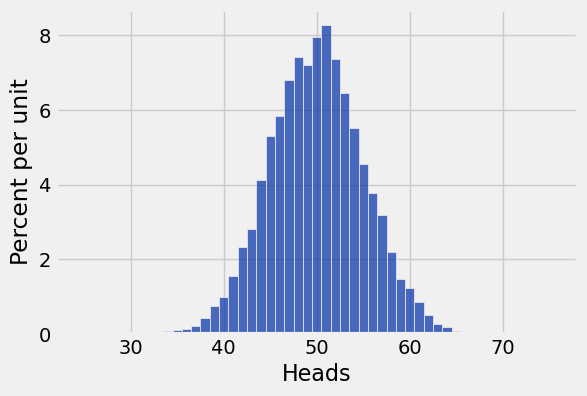

In [9]:
heads = Table().with_column('Heads', outcomes)
heads.hist(bins = np.arange(24.5, 76.5))

# Chance #

### Probability Question

### Another Question

### Complement Rule

### The Monty Hall Problem ###

In [10]:
goats = make_array('first goat', 'second goat')
doors = make_array('car', 'first goat', 'second goat')
doors

array(['car', 'first goat', 'second goat'],
      dtype='<U11')

In [11]:
def other_goat(x):
    if x == 'first goat':
        return 'second goat'
    elif x == 'second goat':
        return 'first goat'

In [12]:
make_array(other_goat('first goat'), other_goat('second goat'))

array(['second goat', 'first goat'],
      dtype='<U11')

In [13]:
def monty_hall():
    """Return 
    [contestant's guess, what Monty reveals, what remains behind the other door]"""
    
    contestant_choice = np.random.choice(doors)
    
    if contestant_choice == 'first goat':
        monty_choice = 'second goat'
        remaining_choice = 'car'
    
    if contestant_choice == 'second goat':
        monty_choice = 'first goat'
        remaining_choice = 'car'
    
    if contestant_choice == 'car':
        monty_choice = np.random.choice(goats)
        remaining_choice = other_goat(monty_choice)
        
    return make_array(contestant_choice, monty_choice, remaining_choice)

In [14]:
monty_hall()

array(['car', 'first goat', 'second goat'],
      dtype='<U11')

In [15]:
results = Table(make_array('Guess', 'Revealed', 'Remaining'))

for i in np.arange(10000):
    results.append(monty_hall())


In [16]:
results.show(3)

Guess,Revealed,Remaining
first goat,second goat,car
car,first goat,second goat
first goat,second goat,car


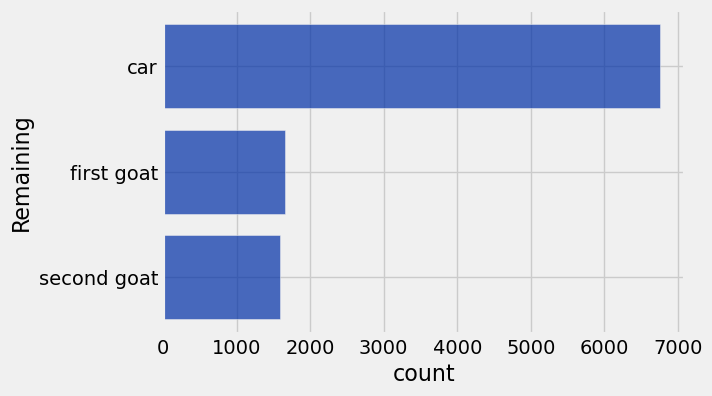

In [17]:
results.group('Remaining').barh('Remaining')

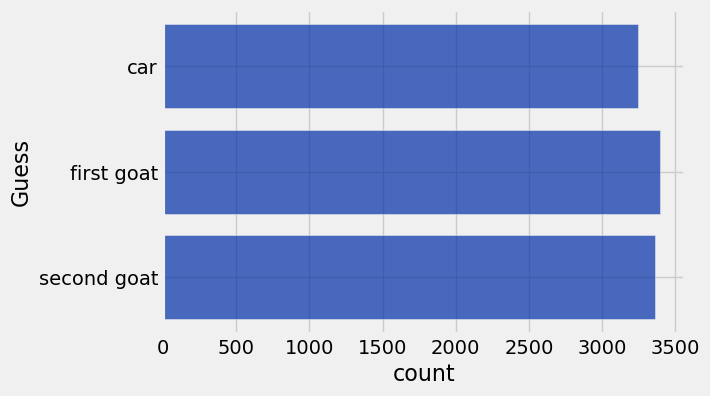

In [18]:
results.group('Guess').barh('Guess')